# Thermodynamic Bethe Ansatz for the XXX spin chain

The XXX spin chain model describes a one-dimensional magnet with nearest  
neighbours antiferromagnetic interactions:

$$H = J \sum_{i=1}^N \left(s_i^x s_{i+1}^x + s_i^y s_{i+1}^y + s_i^z s_{i+1}^z \right) + h \sum_{i=1}^N s_i^z $$

where $J$ is the energy scale ($J=1$ by convention) and $h$ is the external magnetic field. 
The thermodynamics of this model is exactly described by the Yang-Yang equation [Takahashi]:

$$\epsilon_n = \epsilon_n^0 + a_1 * \log
        \left[(1 + e^{-\epsilon_{n-1}})(1 + e^{-\epsilon_{n+1}})\right]$$

In this tutorial we solve this equation numerically using `rapidity` and
compute thermodynamic quantities from the solution.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from rapidity.models import XXXSpinChain, StringModel
from rapidity.core import Grid1D, Field
from rapidity.tba import StringTBAState
from rapidity.utils import plot

## Setting up the model

We define the XXX spin chain and set up a uniform grid.

In [4]:
# define model
model = XXXSpinChain(S=0.5, n_max=5)

# define rapidity grid
grid = Grid1D.uniform(-5, 5, 200, "theta")

print(f"Grid: {len(grid.points)} points")
print(f"Rapidity range: [{grid.points.min():.2f}, {grid.points.max():.2f}]")

Grid: 200 points
Rapidity range: [-5.00, 5.00]


## Solving the TBA equation

We solve the Yang-Yang equation at temperature $T = 0.5$ and magnetic field
 $h = 0.5$. The values are passed as a dictionary
keyed by charge order — charge 2 is the energy and charge 0
is the particle number.

The inverse temperature $\beta = 1/T$ multiplies the energy charge, and
$h/T$ multiplies the magnetization in $z$-direction charge, giving the standard
canonical driving term:

$$\epsilon_0(\theta) = \frac{1}{T} q_2(\theta) + \frac{h}{T} q_0(\theta)$$

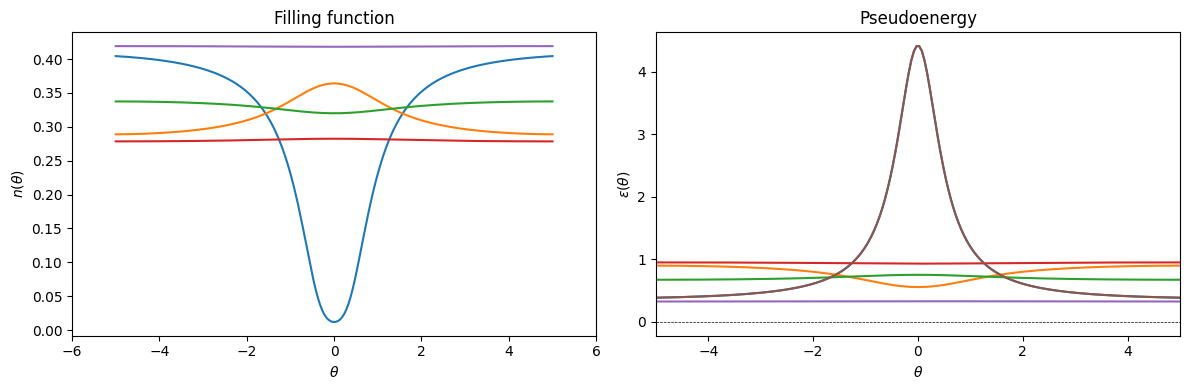

In [13]:
T, h = 1, 0
state = StringTBAState.from_betas(model, grid, betas={2: 1/T, 0: h/T})

# plot filling function
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#plot(state.filling, ax=axes[0])
for n, filling in enumerate(state.filling):
    axes[0].plot(grid.points, filling.values)
    epsilon = np.log((1 - filling.values) / filling.values)
    axes[1].plot(grid.points, epsilon)
axes[0].set_xlabel(r'$\theta$')
axes[0].set_ylabel(r'$n(\theta)$')
axes[0].set_title('Filling function')
axes[0].set_xlim(-6, 6)

# plot pseudoenergy
epsilon = np.log((1 - state.filling[0].values) / state.filling[0].values)
axes[1].plot(grid.points, epsilon)
axes[1].set_xlabel(r'$\theta$')
axes[1].set_ylabel(r'$\epsilon(\theta)$')
axes[1].set_title('Pseudoenergy')
axes[1].set_xlim(-5, 5)
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Thermodynamic quantities

From the filling function we can compute the particle density 
$\rho_p(\theta)$, the state density $\rho_s(\theta)$, and the
effective velocity $v^{eff}(\theta)$.